In [ ]:
# =========================
# STEP 0: Imports
# =========================
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

# =========================
# STEP 1: Load Dataset
# =========================
DATASET_PATH = r"C:\Mini-Project\Alzheimer_Early_Detection\data\raw"
IMG_SIZE = 224

classes = {
    "Alzheimer": 0,
    "MCI": 1,
    "Normal": 2
}

X = []
y = []

print("Loading images...")

for class_name, label in classes.items():
    class_path = os.path.join(DATASET_PATH, class_name)

    for root, _, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                img_path = os.path.join(root, file)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                X.append(img)
                y.append(label)

X = np.array(X, dtype="float32")
y = np.array(y)

print("Total images:", X.shape[0])

# =========================
# STEP 2: Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# STEP 3: CNN Feature Extraction
# =========================
print("Extracting CNN features...")

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

cnn_model = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

X_train_features = cnn_model.predict(X_train, batch_size=16, verbose=1)
X_test_features  = cnn_model.predict(X_test, batch_size=16, verbose=1)

# =========================
# STEP 4: Flatten Features
# =========================
X_train_flat = X_train_features.reshape(X_train_features.shape[0], -1)
X_test_flat  = X_test_features.reshape(X_test_features.shape[0], -1)

# =========================
# STEP 5: PCA (DIM REDUCTION)
# =========================
print("Applying PCA...")

pca = PCA(n_components=300)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)

# =========================
# STEP 6: SVM Training
# =========================
print("Training SVM...")

svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train_pca, y_train)


# =========================
# STEP 7: Evaluation
# =========================
y_pred = svm.predict(X_test_pca)

print("\nSVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# STEP 8: Save Results
# =========================
np.save("X_train_pca.npy", X_train_pca)
np.save("X_test_pca.npy", X_test_pca)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("\nPipeline completed successfully.")


Loading images...


KeyboardInterrupt: 

In [2]:
np.save("X_train_pca.npy", X_train_pca)
np.save("X_test_pca.npy", X_test_pca)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)


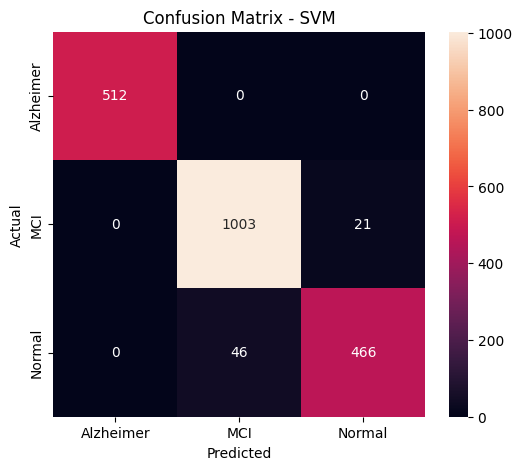

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Alzheimer','MCI','Normal'],
            yticklabels=['Alzheimer','MCI','Normal'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()


In [4]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_pca, y_train)

y_pred_lr = lr.predict(X_test_pca)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


LR Accuracy: 0.90234375
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       512
           1       0.90      0.90      0.90      1024
           2       0.81      0.80      0.80       512

    accuracy                           0.90      2048
   macro avg       0.90      0.90      0.90      2048
weighted avg       0.90      0.90      0.90      2048



In [5]:
print(y_pred[:10])
print(y_test[:10])


[1 0 2 2 1 0 1 1 1 2]
[1 0 2 2 1 0 1 1 1 2]


In [6]:
import os

img_path = r"C:\Mini-Project\Alzheimer_Early_Detection\data\raw\Alzheimer\ModerateDemented\ModerateImpairment (1).jpg"

print(os.path.exists(img_path))


True


In [7]:
import cv2

img = cv2.imread(img_path)
if img is None:
    raise ValueError("Image could not be loaded")

img = cv2.resize(img, (224,224))
img = img / 255.0
img = np.expand_dims(img, axis=0)

print("Image ready for prediction.")

class_names = ['Alzheimer', 'MCI', 'Normal']

features = cnn_model.predict(img)
features_flat = features.reshape(1, -1)
features_pca = pca.transform(features_flat)

prediction = svm.predict(features_pca)
confidence = svm.predict_proba(features_pca)

print("Predicted class:", class_names[prediction[0]])
print("Confidence:", round(np.max(confidence)*100, 2), "%")


Image ready for prediction.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
Predicted class: Alzheimer
Confidence: 99.59 %


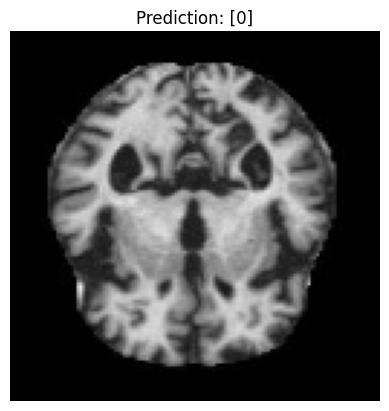

In [8]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
plt.title(f"Prediction: {prediction}")
plt.axis('off')
plt.show()


In [9]:
import joblib

# Save trained models
joblib.dump(pca, "pca_model.pkl")
joblib.dump(svm, "svm_model.pkl")

# Save reduced features (optional but recommended)
np.save("X_train_pca.npy", X_train_pca)
np.save("X_test_pca.npy", X_test_pca)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("Models and features saved successfully.")


Models and features saved successfully.


In [10]:
from collections import Counter
print(Counter(y_train))
from sklearn.svm import SVC

model = SVC(kernel='rbf', class_weight='balanced')


Counter({np.int64(1): 4096, np.int64(0): 2048, np.int64(2): 2048})


In [11]:
print(set(y_train))


{np.int64(0), np.int64(1), np.int64(2)}


In [1]:
pip install streamlit joblib matplotlib seaborn

  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached pyarrow-23.0.1-cp313-cp313-win_amd64.whl.metadata (3.1 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.2-py3-none-any.whl.metadata (4.3 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
 


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import joblib

joblib.dump(svm, "svm_model.pkl")
joblib.dump(pca, "pca_model.pkl")

print("Models saved successfully")

Models saved successfully


In [1]:
pca = PCA(n_components=100)

NameError: name 'PCA' is not defined